<a href="https://colab.research.google.com/github/asumaira432-art/library_management/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv(r'/content/sample_data/student_exam_scores.csv')
print(df.head(10))

  student_id  hours_studied  sleep_hours  attendance_percent  previous_scores  \
0       S001            8.0          8.8                72.1               45   
1       S002            1.3          8.6                60.7               55   
2       S003            4.0          8.2                73.7               86   
3       S004            3.5          4.8                95.1               66   
4       S005            9.1          6.4                89.8               71   
5       S006            8.4          5.1                58.5               75   
6       S007           10.8          6.0                54.2               88   
7       S008            2.0          4.3                75.8               55   
8       S009            5.6          5.9                81.6               84   
9       S010            1.3          8.9                66.8               70   

   exam_score  
0        30.2  
1        25.0  
2        35.8  
3        34.0  
4        40.3  
5        35.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
None


In [ ]:
x = df["hours_studied,sleep_hours,attendance_present,previous_scores"]
y = df["exam_score"]

In [ ]:
print(df.corr(numeric_only=True))

                    hours_studied  sleep_hours  attendance_percent  \
hours_studied            1.000000     0.077864           -0.031311   
sleep_hours              0.077864     1.000000            0.000572   
attendance_percent      -0.031311     0.000572            1.000000   
previous_scores          0.069078    -0.194251            0.051958   
exam_score               0.776751     0.188222            0.225713   

                    previous_scores  exam_score  
hours_studied              0.069078    0.776751  
sleep_hours               -0.194251    0.188222  
attendance_percent         0.051958    0.225713  
previous_scores            1.000000    0.431105  
exam_score                 0.431105    1.000000  


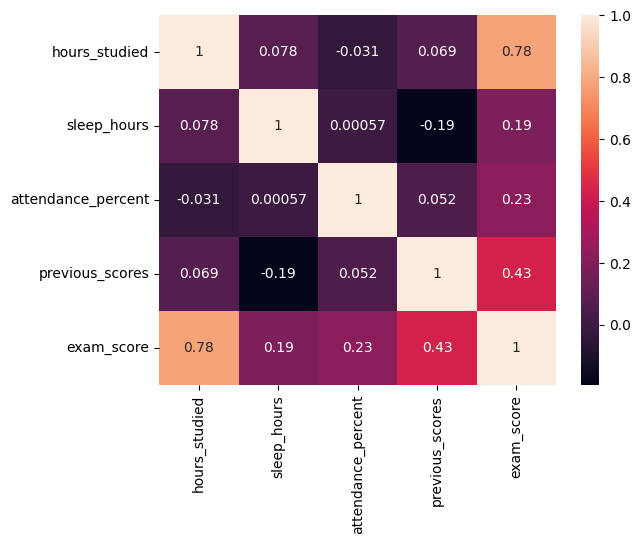

In [ ]:
import seaborn as sns
sns.heatmap(df.drop('student_id', axis = 1).corr(), annot=True)
plt.show()

In [ ]:
x = df[["hours_studied", "sleep_hours", "attendance_percent", "previous_scores"]]
y = df["exam_score"]
#training, testing, dataset split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print("r2 score", r2_score(y_test, y_pred))
print("mean squared error", mean_squared_error(y_test, y_pred))

r2 score 0.8537447137159516
mean squared error 7.761782668623075


In [ ]:
print("training accuracy", model.score(x_train, y_train))
print("testing accuracy", model.score(x_test, y_test))

training accuracy 0.83642950148381
testing accuracy 0.8537447137159516


In [ ]:
#user input
hours_studied = float(input("hours studied: "))
sleep_hours = float(input("sleep hours: "))
attendance_percent = float(input("attendance percent: "))
previous_scores = float(input("previous scores: "))

# Create a DataFrame for the new input with feature names
input_data = pd.DataFrame([{
    'hours_studied': hours_studied,
    'sleep_hours': sleep_hours,
    'attendance_percent': attendance_percent,
    'previous_scores': previous_scores
}])

# Make prediction
prediction = model.predict(input_data)[0]

# Print the prediction
print(f"Predicted exam_score: {prediction:.2f}")